In [14]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt
import numpy as np


Load the MNIST dataset

In [15]:
(train_data,train_target),(test_data,test_target) = mnist.load_data()

Visualize the dataset

Target labels:  [5 0 8 6 7 6 9 9 3 7]


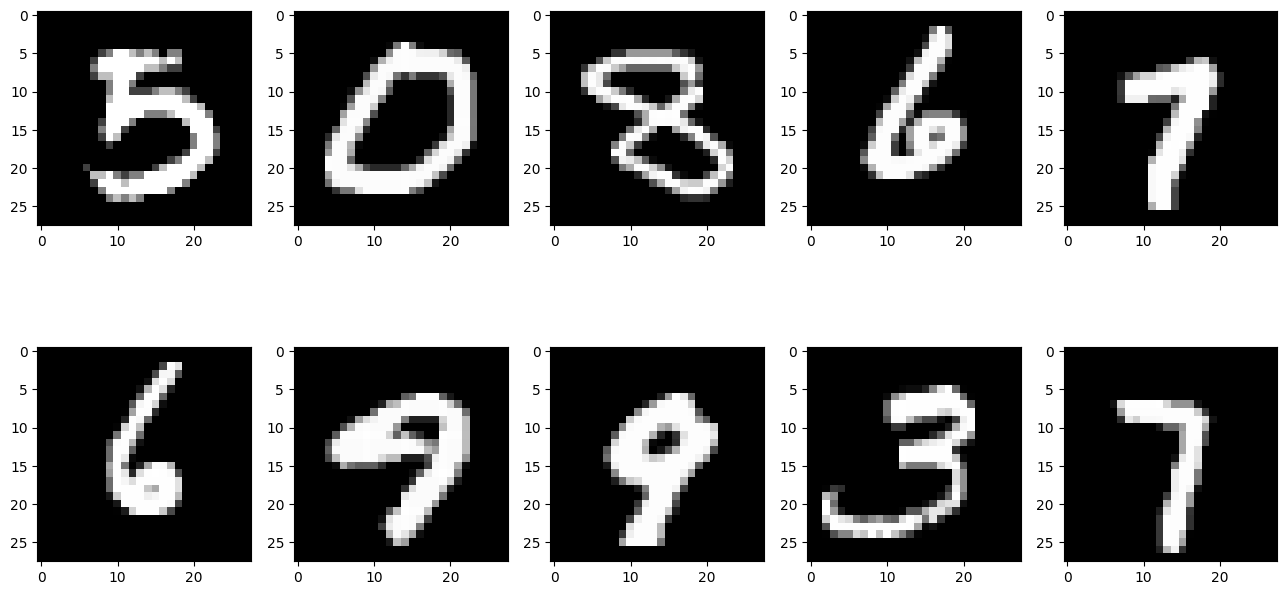

In [16]:
fig, axs = plt.subplots(2, 5, figsize=(16,8))
random_numbers = np.random.randint(0, 60000, 10)
print('Target labels: ',train_target[random_numbers])
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(train_data[random_numbers[idx]],cmap='gray')
plt.show()

Pre-processing stage

In [17]:
new_train_data = train_data/255.0
new_test_data=test_data/255.0

new_train_target = to_categorical(train_target)
new_test_target = to_categorical(test_target)

Create the Model architecture

In [19]:
from tensorflow.keras.regularizers import l1_l2
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))

model.add(Dense(512, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)))
model.add(Dense(256, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)))

model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [21]:
train_info = model.fit(new_train_data, new_train_target, epochs=20, validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8942 - loss: 0.5507 - val_accuracy: 0.9720 - val_loss: 0.2581
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9706 - loss: 0.2475 - val_accuracy: 0.9793 - val_loss: 0.2022
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - accuracy: 0.9774 - loss: 0.1987 - val_accuracy: 0.9768 - val_loss: 0.1858
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.9811 - loss: 0.1625 - val_accuracy: 0.9763 - val_loss: 0.1744
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9827 - loss: 0.1457 - val_accuracy: 0.9720 - val_loss: 0.1792
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.9853 - loss: 0.1279 - val_accuracy: 0.9792 - val_loss: 0.1510
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9871 - loss: 0.1160 - val_accuracy: 0.9803 - val_loss: 0.1383
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.9869 -

Plot the loss and accuracy graphs

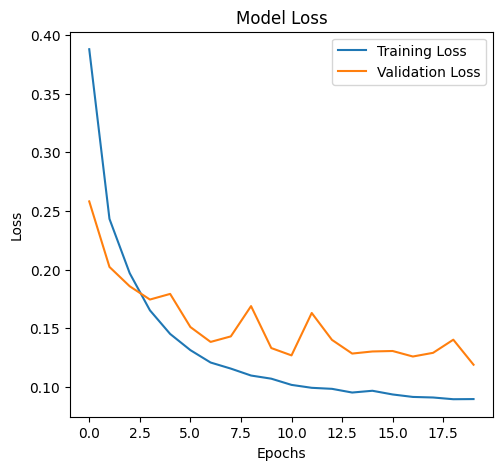

In [23]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_info.history['loss'], label='Training Loss')
plt.plot(train_info.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

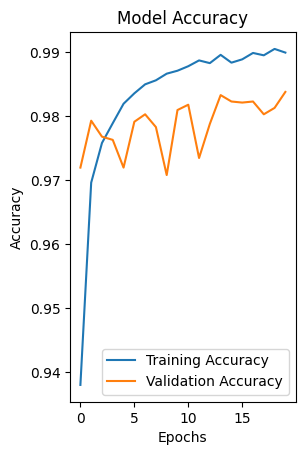

In [24]:
plt.subplot(1, 2, 2)
plt.plot(train_info.history['accuracy'], label='Training Accuracy')
plt.plot(train_info.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

Test the performance of Model

In [25]:
loss, acc = model.evaluate(new_test_data , new_test_target)
print(f'Loss of the Test dataset is: {loss}\nAccuracy of the test dataset is: {acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9770 - loss: 0.1375
Loss of the Test dataset is: 0.1198321059346199
Accuracy of the test dataset is: 0.9818999767303467


Save the model weights

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<Figure size 1000x800 with 0 Axes>

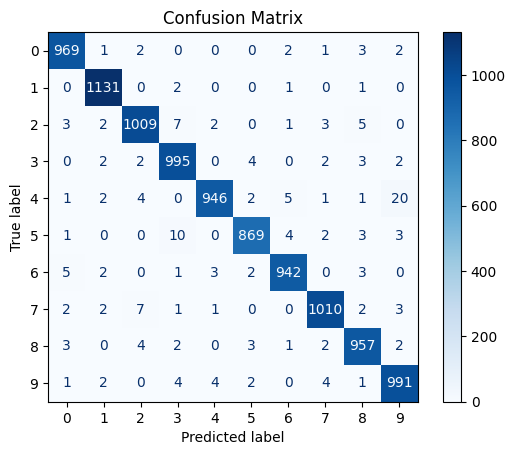

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_one_hot = model.predict(new_test_data)
y_pred = np.argmax(y_pred_one_hot, axis=1)
y_true = np.argmax(new_test_target, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [28]:
model.save_weights('MNIST_WEIGHTS_V1.weights.h5')